# ACC102 Mini Assignment: Calorie Burn Efficiency Analysis & Prediction

## 1. Project Overview & Problem Definition

**Analytical Problem:**
In the health and fitness industry, understanding how different lifestyle and physiological factors impact calorie-burning efficiency is crucial. This project aims to analyze a health-tracking dataset to classify and predict "Calorie Burn Efficiency." By applying data preprocessing, feature engineering, and a Random Forest classification model, this analysis identifies the key drivers behind high and low metabolic efficiency.

**Target Audience / User:**
The intended users of this data product are **fitness app developers** and **health coaches**. They can use the insights and the trained predictive model to provide personalized workout and lifestyle recommendations (e.g., adjusting activity intensity or hydration) to help clients achieve their fitness goals more effectively.

**Dataset Justification:**
The dataset (`calorie_efficiency_dataset.csv`) contains key biometric and lifestyle metrics (such as BMI, active minutes, sleep hours, and heart rate). It is highly relevant to the business context of digital health and personalized fitness services.

## 2. Setup & Data Loading

In this section, we import the necessary Python libraries for data manipulation, machine learning, and visualization. We also define a relative output directory to ensure the reproducibility of this notebook (so the marker can easily run it locally).

In [1]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from IPython.display import display

# Set display options for better readability
pd.set_option('display.max_colwidth', None)

# Define relative output directory for reproducibility
output_dir = "./output"
os.makedirs(output_dir, exist_ok=True)

def load_data(path):
    """Load the dataset from the given path."""
    return pd.read_csv(path)

# Load the dataset (Assuming the CSV is in the same directory as the notebook)
dataset_path = "calorie_efficiency_dataset.csv"

try:
    df = load_data(dataset_path)
    print("Data loaded successfully. Here is a quick preview:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: Could not find '{dataset_path}'. Please ensure the data file is in the same folder as this notebook.")

Matplotlib is building the font cache; this may take a moment.


Data loaded successfully. Here is a quick preview:


,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency


## 3. Data Preprocessing & Feature Engineering

To ensure the model learns effectively, we must clean the data by capping extreme outliers and engineering new business-relevant features. For example, `activity_intensity` (active minutes relative to daily steps) is a much stronger indicator of a workout's quality than step count alone.

In [2]:
def preprocess_and_engineer(df):
    """Clean data and create new advanced features."""
    df_clean = df.copy()
    
    # Drop irrelevant columns if they exist
    if "efficiency_score" in df_clean.columns:
        df_clean = df_clean.drop(columns=["efficiency_score"])
        
    # Cap extreme outliers (1st and 99th percentiles)
    num_cols = df_clean.select_dtypes(include=np.number).columns
    for col in num_cols:
        df_clean[col] = np.clip(df_clean[col], df_clean[col].quantile(0.01), df_clean[col].quantile(0.99))
        
    # Feature Engineering
    df_clean["activity_intensity"] = df_clean["active_minutes"] / (df_clean["steps_per_day"] + 1)
    df_clean["fitness_ratio"] = df_clean["muscle_mass_ratio"] / (df_clean["body_fat_percentage"] + 1e-5)
    df_clean["recovery_score"] = df_clean["sleep_hours"] * df_clean["hydration_liters"]
    df_clean["cardio_efficiency"] = df_clean["heart_rate_resting"] / (df_clean["heart_rate_avg"] + 1)
    
    return df_clean

# Apply transformations
df_processed = preprocess_and_engineer(df)
print("Feature engineering completed. Current shape:", df_processed.shape)

Feature engineering completed. Current shape: (1000000, 18)


## 4. Handling Imbalanced Data (SMOTE)

In fitness datasets, "High Efficiency" users are often rare compared to "Low Efficiency" users. Training a model on such imbalanced data leads to biased predictions. Here, we apply Synthetic Minority Over-sampling Technique (SMOTE) to balance the classes and save the distribution charts for our interactive frontend.

--- Class Distribution BEFORE SMOTE ---


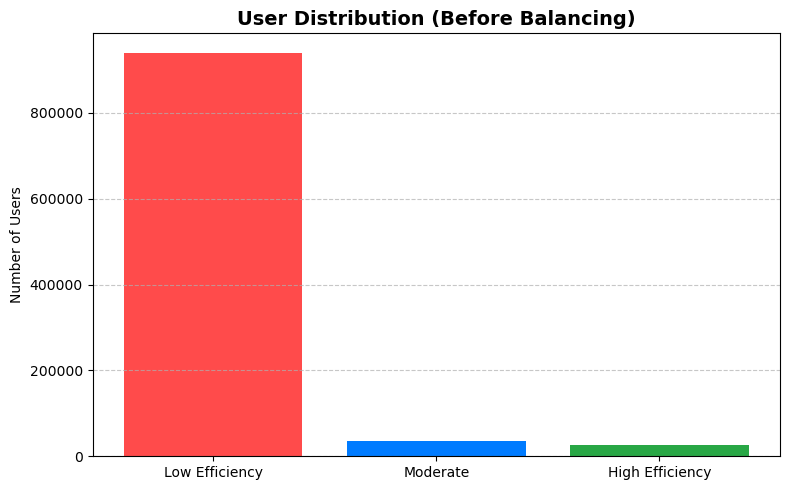

--- Class Distribution AFTER SMOTE ---


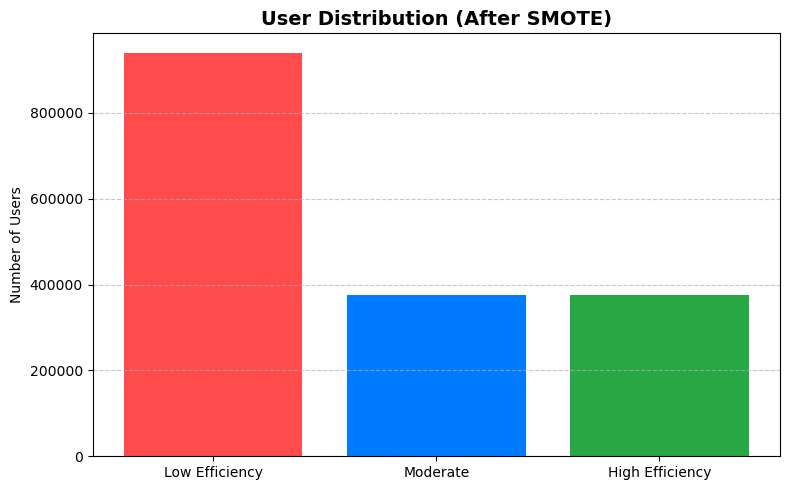

In [3]:
# Separate features and target
target_col = "calorie_efficiency"
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# Helper function to plot and save class distributions
def plot_and_save_distribution(y_series, filename, title):
    dist = y_series.value_counts().reset_index()
    dist.columns = ['Class', 'Count']
    dist['Percentage'] = (dist['Count'] / len(y_series)) * 100
    
    plt.figure(figsize=(8, 5))
    bars = plt.bar(dist['Class'], dist['Count'], color=['#FF4B4B', '#007BFF', '#28A745'])
    plt.title(title, fontsize=14, fontweight='bold')
    plt.ylabel('Number of Users')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Save for frontend usage
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}.png", dpi=300)
    dist.to_csv(f"{output_dir}/{filename}.csv", index=False)
    plt.show()
    return dist

# Plot Before SMOTE
print("--- Class Distribution BEFORE SMOTE ---")
dist_before = plot_and_save_distribution(y, "distribution_before", "User Distribution (Before Balancing)")

# Apply SMOTE
class_counts = y.value_counts()
target_size = int(class_counts.max() * 0.4) # Adjusting minority classes to 40% of majority
strategy = {cls: target_size for cls in class_counts.index if class_counts[cls] < target_size}

sm = SMOTE(sampling_strategy=strategy, random_state=42)
X_resampled, y_resampled = sm.fit_resample(X, y)

# Plot After SMOTE
print("--- Class Distribution AFTER SMOTE ---")
dist_after = plot_and_save_distribution(y_resampled, "distribution_after", "User Distribution (After SMOTE)")

## 5. Model Training & Business Insights

We train a Random Forest Classifier to predict the metabolic efficiency. Furthermore, we extract the "Feature Importance" to understand which factors truly drive fat burning. This insight will be displayed on our frontend app to persuade users to purchase relevant fitness courses.

Classification Report:
                 precision    recall  f1-score   support

High Efficiency       0.30      0.76      0.43     75060
 Low Efficiency       0.76      0.51      0.61    187649
       Moderate       0.87      0.25      0.39     75059

       accuracy                           0.51    337768
      macro avg       0.64      0.51      0.48    337768
   weighted avg       0.68      0.51      0.52    337768



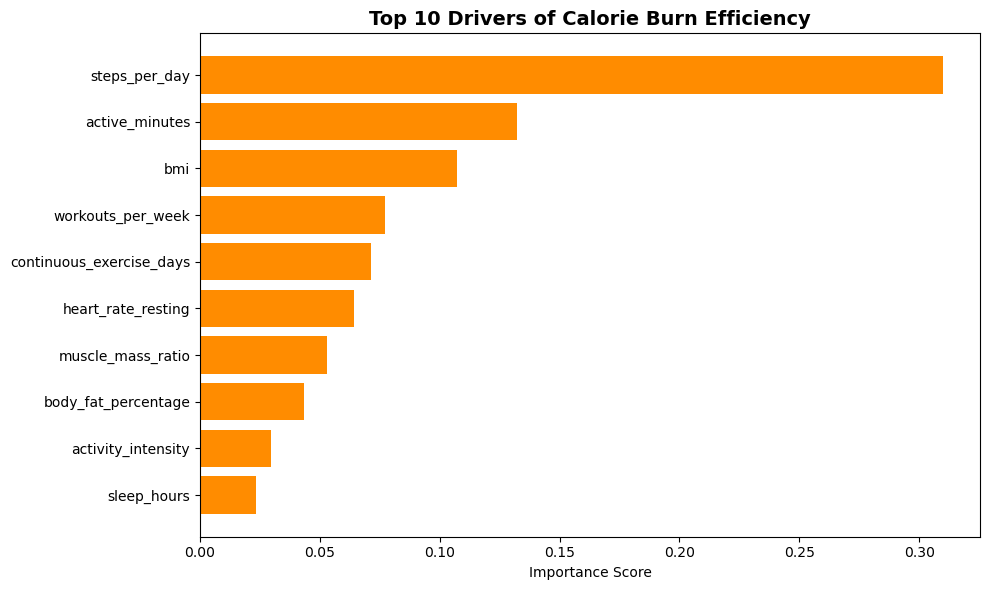


[Success] Model successfully saved to relative path: ./rf_model.pkl


In [5]:
import joblib

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, stratify=y_resampled, random_state=42)

# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, class_weight="balanced", random_state=42)
rf_model.fit(X_train, y_train)

# Model Evaluation
preds = rf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, preds))

# Extract Feature Importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=True) # Ascending for horizontal bar chart

# Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"].tail(10), feature_importance["Importance"].tail(10), color='#FF8C00')
plt.title("Top 10 Drivers of Calorie Burn Efficiency", fontsize=14, fontweight='bold')
plt.xlabel("Importance Score")
plt.tight_layout()

# Save chart and data for Streamlit App
plt.savefig("feature_importance.png", bbox_inches='tight', dpi=300)
plt.show()

# Export the trained model using RELATIVE PATH
model_save_path = "rf_model.pkl"
joblib.dump(rf_model, model_save_path)
print(f"\n[Success] Model successfully saved to relative path: ./{model_save_path}")